# MTG FCI quicklook e crop Italia

Questo notebook ricompone tutti i file `CHK-BODY` di un prodotto `MTG FCI L1c` in un unico mosaico `Q4`.

Per questo motivo l'immagine non appare piu' come una striscia bassa e molto larga: quella era solo una singola scansione del prodotto, non il quarter completo.

Il notebook permette di:
- elencare i prodotti disponibili;
- selezionare un prodotto nel tempo;
- ricomporre il mosaico completo per ciascun canale;
- ritagliare direttamente l'area dell'Italia in coordinate geografiche;
- plottare quicklook full-quarter e quicklook Italia.

In [5]:
# Se il kernel non ha ancora tutte le dipendenze, scommenta la riga seguente.
# %pip install xarray netCDF4 matplotlib pandas pyproj requests

from pathlib import Path
import importlib
import sys

PROJECT_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"C:/Users/Daniele.LOKI/Documents/medicanes/MTG_data"),
]
for candidate in PROJECT_DIR_CANDIDATES:
    if (candidate / "mtg_fci_tools.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mtg_fci_tools
importlib.reload(mtg_fci_tools)

from mtg_fci_tools import (
    CENTRAL_ITALY_BBOX,
    ITALY_BBOX,
    ROME_BBOX,
    TARGET_LAT,
    TARGET_LON,
    THERMAL_CHANNEL,
    PLOT_CHANNELS,
    VISIBLE_CHANNEL,
    VNIR_CHANNELS,
    channel_title,
    crop_channel_by_bbox,
    crop_image_by_bbox,
    crop_channel_with_plan,
    fetch_coastline_lines,
    fetch_gra_lines,
    filter_lonlat_lines_by_bbox,
    list_body_files,
    list_products,
    make_crop_plan,
    mosaic_channel,
    plot_image,
    plot_lonlat_grid,
    plot_lonlat_lines,
    plot_lonlat_point,
    plot_rgb_image,
    resolve_base_dir,
    sandwich_composite,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["image.origin"] = "lower"
plt.rcParams["image.interpolation"] = "nearest"

In [6]:
BASE_DIR = resolve_base_dir("mtg_20260603_q4")

print(f"Working directory notebook: {Path.cwd()}")
print(f"Dataset trovato in:       {BASE_DIR}")

Working directory notebook: C:\Windows\system32
Dataset trovato in:       C:\Users\Daniele.LOKI\Documents\medicanes\MTG_data\mtg_20260603_q4


In [15]:
# Definizioni spostate in mtg_fci_tools.py


In [16]:
# Utility di mosaico, crop, sandwich e overlay importate da mtg_fci_tools.py


In [7]:
products = list_products(BASE_DIR)
product_table = pd.DataFrame(
    {
        "product_index": range(len(products)),
        "product_name": [p.name for p in products],
        "body_chunk_count": [len(list_body_files(p)) for p in products],
    }
)
product_table

,product_index,product_name,body_chunk_count
0,0,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RR...",12
1,1,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RR...",12
2,2,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RR...",12
3,3,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RR...",12
4,4,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RR...",12
5,5,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RR...",12
6,6,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RR...",12
7,7,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RR...",12
8,8,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RR...",12
9,9,"W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RR...",12


In [8]:
# Cambia questo indice per scegliere un diverso time step.
PRODUCT_INDEX = 5

product_dir = products[PRODUCT_INDEX]
body_files = list_body_files(product_dir)
sample_file = body_files[0]

print(f"Prodotto selezionato: {product_dir.name}")
print(f"Numero di chunk body: {len(body_files)}")
print(f"Primo chunk body: {sample_file.name}")
print(f"Bounding box Italia:        {ITALY_BBOX}")
print(f"Bounding box Centro Italia: {CENTRAL_ITALY_BBOX}")
print(f"Bounding box Roma:          {ROME_BBOX}")

Prodotto selezionato: W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--x-x---x_C_EUMT_20260603055319_IDPFI_OPE_20260603055003_20260603055935_N__O_0036_0000
Numero di chunk body: 12
Primo chunk body: W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20260603055928_IDPFI_OPE_20260603055639_20260603055735_N__O_0036_0029.nc
Bounding box Italia:        {'lon_min': 6.0, 'lon_max': 19.0, 'lat_min': 36.0, 'lat_max': 48.0}
Bounding box Centro Italia: {'lon_min': 10.5, 'lon_max': 14.5, 'lat_min': 40.5, 'lat_max': 43.3}
Bounding box Roma:          {'lon_min': 12.2, 'lon_max': 12.85, 'lat_min': 41.65, 'lat_max': 42.1}


In [9]:
# Piani di crop riutilizzabili: utili soprattutto per produrre video su molti time frame.
ITALY_PLANS = {channel: make_crop_plan(product_dir, channel, ITALY_BBOX) for channel in PLOT_CHANNELS}
CENTRAL_ITALY_PLANS = {channel: make_crop_plan(product_dir, channel, CENTRAL_ITALY_BBOX) for channel in PLOT_CHANNELS}
ROME_PLANS = {channel: make_crop_plan(product_dir, channel, ROME_BBOX) for channel in PLOT_CHANNELS}

print("Chunk letti per crop Italia:", {channel: len(plan.chunks) for channel, plan in ITALY_PLANS.items()})
print("Chunk letti per crop Centro:", {channel: len(plan.chunks) for channel, plan in CENTRAL_ITALY_PLANS.items()})
print("Chunk letti per crop Roma:  ", {channel: len(plan.chunks) for channel, plan in ROME_PLANS.items()})

Chunk letti per crop Italia: {'vis_06': 4, 'ir_105': 4}
Chunk letti per crop Centro: {'vis_06': 1, 'ir_105': 1}
Chunk letti per crop Roma:   {'vis_06': 1, 'ir_105': 1}


In [10]:
summary_rows = []
for channel in PLOT_CHANNELS:
    italy_image, _, _ = crop_channel_with_plan(product_dir, ITALY_PLANS[channel])
    summary_rows.append(
        {
            "channel": channel,
            "italy_shape": tuple(italy_image.shape),
            "crop_chunks": len(ITALY_PLANS[channel].chunks),
            "type": "VNIR" if channel in VNIR_CHANNELS else "IR/WV",
        }
    )
pd.DataFrame(summary_rows)

,channel,italy_shape,crop_chunks,type
0,vis_06,"(866, 1191)",4,VNIR
1,ir_105,"(433, 596)",4,IR/WV


## Disc - Italy images

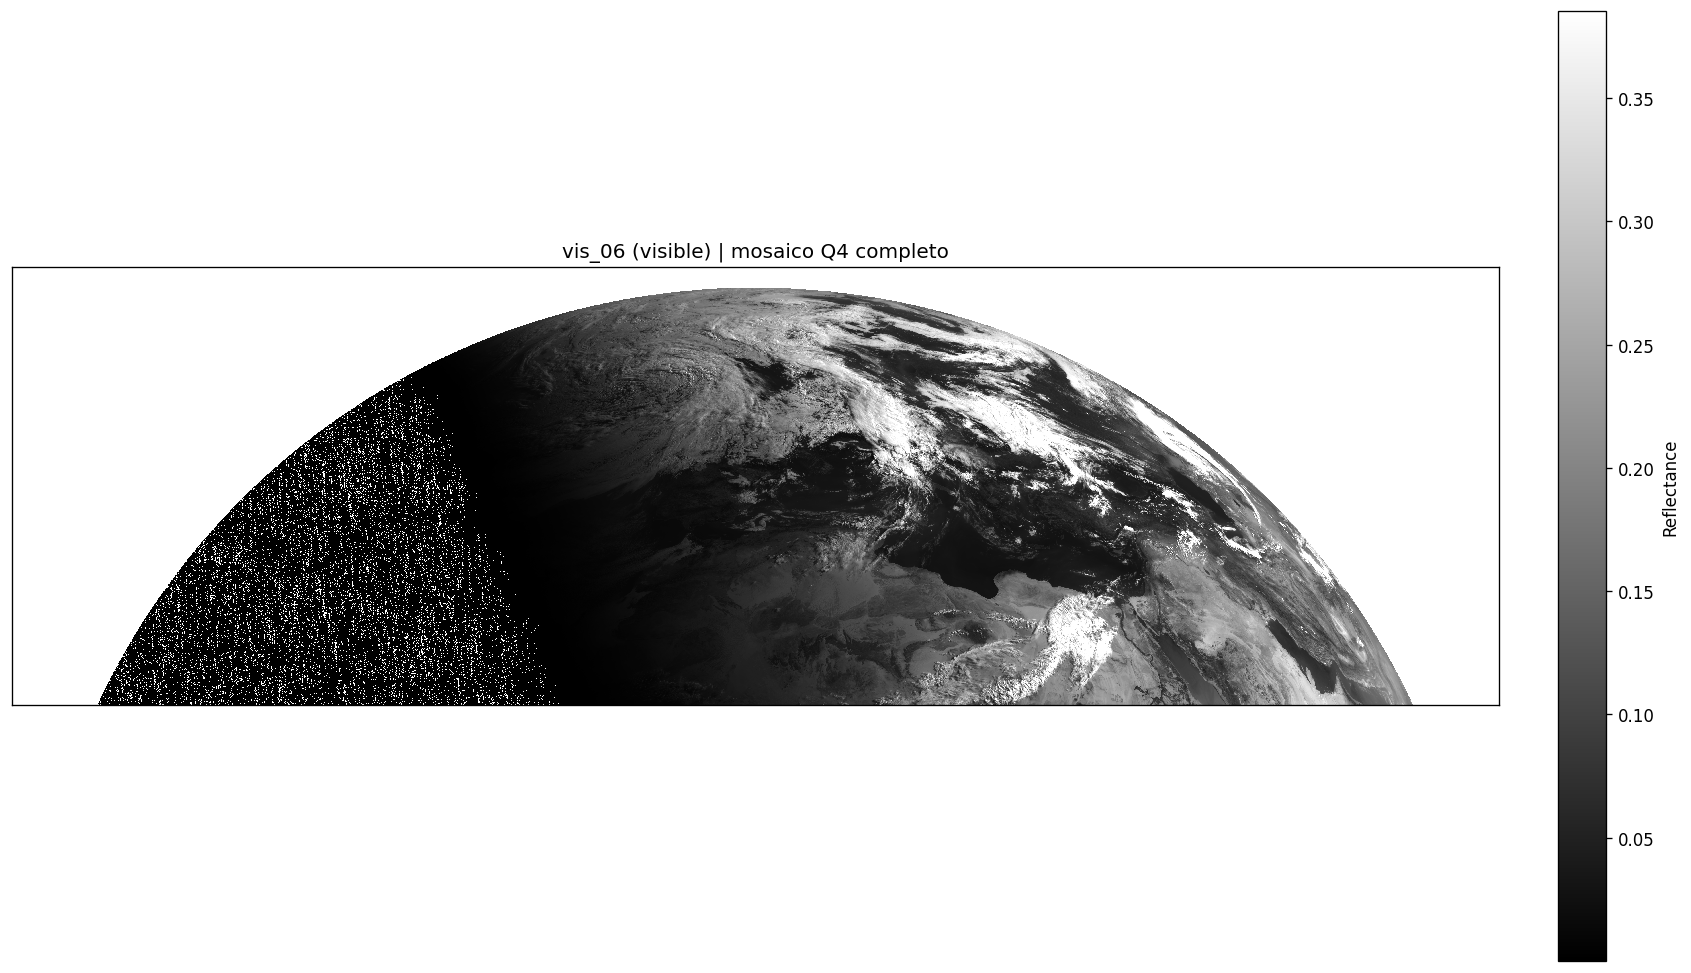

In [8]:
# Quicklook full-quarter del canale visibile.
FULL_CHANNEL = VISIBLE_CHANNEL

full_image, x_full, y_full = mosaic_channel(product_dir, FULL_CHANNEL)
fig, ax = plt.subplots(figsize=(14, 8), constrained_layout=True)
plot_image(ax, full_image, FULL_CHANNEL, f"{channel_title(FULL_CHANNEL)} | mosaico Q4 completo")
plt.show()

In [ ]:
# Crop Italia del canale visibile, letto direttamente dal bbox senza mosaico completo.
ITALY_CHANNEL = VISIBLE_CHANNEL

italy_image, italy_x, italy_y = crop_channel_with_plan(product_dir, ITALY_PLANS[ITALY_CHANNEL])

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
plot_image(ax, italy_image, ITALY_CHANNEL, f"{channel_title(ITALY_CHANNEL)} | area Italia")
plt.show()

In [ ]:
# Confronto tra canale visibile e canale IR finestra (~10.5 um, il piu' vicino a 10.8 um nei file disponibili).
fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax, channel in zip(axes, PLOT_CHANNELS):
    italy_image, _, _ = crop_channel_with_plan(product_dir, ITALY_PLANS[channel])
    plot_image(ax, italy_image, channel, channel_title(channel))

fig.suptitle(f"Area Italia | {product_dir.name}", fontsize=12)
plt.show()

In [ ]:
# Crop molto ristretto sull'area di Roma per il canale visibile.
rome_vis, _, _ = crop_channel_with_plan(product_dir, ROME_PLANS[VISIBLE_CHANNEL])

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
plot_image(ax, rome_vis, VISIBLE_CHANNEL, f"{channel_title(VISIBLE_CHANNEL)} | area di Roma")
plt.show()

In [ ]:
# Confronto Roma: visibile e IR finestra.
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
for ax, channel in zip(axes, PLOT_CHANNELS):
    rome_image, _, _ = crop_channel_with_plan(product_dir, ROME_PLANS[channel])
    plot_image(ax, rome_image, channel, f"{channel_title(channel)} | Roma")

fig.suptitle(f"Area di Roma | {product_dir.name}", fontsize=12)
plt.show()

## Sandwich Image

Implementazione pratica di una `sandwich image` nello stile operativo EUMETSAT:
- texture visibile da `vis_06`;
- colore da cloud-top temperature su `ir_105`;
- blending moltiplicativo per mantenere la tessitura del VIS.

Nota: questa e' una realizzazione coerente con la descrizione EUMETSAT che hai riportato, ma non pretende di replicare una LUT ufficiale esatta.

In [ ]:
# Sandwich image sull'Italia.
italy_vis, _, _ = crop_channel_with_plan(product_dir, ITALY_PLANS[VISIBLE_CHANNEL])
italy_ir, _, _ = crop_channel_with_plan(product_dir, ITALY_PLANS[THERMAL_CHANNEL])
italy_sandwich = sandwich_composite(italy_vis, italy_ir)

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
plot_rgb_image(ax, italy_sandwich, "Sandwich image | area Italia")
plt.show()

In [ ]:
# Sandwich image sull'area di Roma.
rome_vis, _, _ = crop_channel_with_plan(product_dir, ROME_PLANS[VISIBLE_CHANNEL])
rome_ir, _, _ = crop_channel_with_plan(product_dir, ROME_PLANS[THERMAL_CHANNEL])
rome_sandwich = sandwich_composite(rome_vis, rome_ir)

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
plot_rgb_image(ax, rome_sandwich, "Sandwich image | area di Roma")
plt.show()

In [ ]:
# Overlay geografici: linee di costa e, se disponibile, Grande Raccordo Anulare.
coastline_lines = fetch_coastline_lines()
ITALY_COASTLINE_LINES = filter_lonlat_lines_by_bbox(coastline_lines, ITALY_BBOX, pad_degrees=0.75)
CENTRAL_ITALY_COASTLINE_LINES = filter_lonlat_lines_by_bbox(coastline_lines, CENTRAL_ITALY_BBOX, pad_degrees=0.75)
ROME_COASTLINE_LINES = filter_lonlat_lines_by_bbox(coastline_lines, ROME_BBOX, pad_degrees=0.75)
try:
    gra_lines = fetch_gra_lines()
    ITALY_GRA_LINES = filter_lonlat_lines_by_bbox(gra_lines, ITALY_BBOX, pad_degrees=0.05)
    CENTRAL_ITALY_GRA_LINES = filter_lonlat_lines_by_bbox(gra_lines, CENTRAL_ITALY_BBOX, pad_degrees=0.05)
    ROME_GRA_LINES = filter_lonlat_lines_by_bbox(gra_lines, ROME_BBOX, pad_degrees=0.05)
except Exception as exc:
    gra_lines = []
    ITALY_GRA_LINES = []
    CENTRAL_ITALY_GRA_LINES = []
    ROME_GRA_LINES = []
    print(f"G.R.A. non disponibile al momento: {exc}")

print(f"Segmenti costa globali caricati: {len(coastline_lines)}")
print(f"Segmenti costa Italia usati:     {len(ITALY_COASTLINE_LINES)}")
print(f"Segmenti costa Centro usati:     {len(CENTRAL_ITALY_COASTLINE_LINES)}")
print(f"Segmenti costa Roma usati:       {len(ROME_COASTLINE_LINES)}")
print(f"Segmenti G.R.A. Italia usati:    {len(ITALY_GRA_LINES)}")
print(f"Segmenti G.R.A. Centro usati:    {len(CENTRAL_ITALY_GRA_LINES)}")
print(f"Segmenti G.R.A. Roma usati:      {len(ROME_GRA_LINES)}")

## Overlay geografici

Le celle seguenti aggiungono linee di costa e, sull'area di Roma, il tracciato del G.R.A. ricavato da OpenStreetMap/Overpass e messo in cache locale.

In [ ]:
# Area Italia: visibile con linee di costa.
coastline_lines = globals().get("coastline_lines", fetch_coastline_lines())
ITALY_COASTLINE_LINES = globals().get(
    "ITALY_COASTLINE_LINES",
    filter_lonlat_lines_by_bbox(coastline_lines, ITALY_BBOX, pad_degrees=0.75),
)
italy_vis, italy_x, italy_y = crop_channel_with_plan(product_dir, ITALY_PLANS[VISIBLE_CHANNEL])

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
plot_image(ax, italy_vis, VISIBLE_CHANNEL, f"{channel_title(VISIBLE_CHANNEL)} | area Italia + coste")
plot_lonlat_lines(ax, ITALY_COASTLINE_LINES, italy_x, italy_y, sample_file, color="cyan", linewidth=0.8, alpha=0.9)
plt.show()

In [ ]:
# Area Italia: sandwich image con costa, G.R.A. e griglia lat/lon.
coastline_lines = globals().get("coastline_lines", fetch_coastline_lines())
ITALY_COASTLINE_LINES = globals().get(
    "ITALY_COASTLINE_LINES",
    filter_lonlat_lines_by_bbox(coastline_lines, ITALY_BBOX, pad_degrees=0.75),
)
if "ITALY_GRA_LINES" not in globals():
    try:
        ITALY_GRA_LINES = filter_lonlat_lines_by_bbox(fetch_gra_lines(), ITALY_BBOX, pad_degrees=0.05)
    except Exception as exc:
        ITALY_GRA_LINES = []
        print(f"G.R.A. non disponibile al momento: {exc}")

italy_vis, italy_x, italy_y = crop_channel_with_plan(product_dir, ITALY_PLANS[VISIBLE_CHANNEL])
italy_ir, _, _ = crop_channel_with_plan(product_dir, ITALY_PLANS[THERMAL_CHANNEL])
italy_sandwich = sandwich_composite(italy_vis, italy_ir)

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
plot_rgb_image(ax, italy_sandwich, "Sandwich image | Italia + costa + G.R.A.")
plot_lonlat_grid(ax, italy_x, italy_y, sample_file, ITALY_BBOX, lon_step=2.0, lat_step=2.0, color="white", linewidth=0.5, alpha=0.30, fontsize=8)
plot_lonlat_lines(ax, ITALY_COASTLINE_LINES, italy_x, italy_y, sample_file, color="white", linewidth=0.8, alpha=0.8)
if ITALY_GRA_LINES:
    plot_lonlat_lines(ax, ITALY_GRA_LINES, italy_x, italy_y, sample_file, color="yellow", linewidth=1.3, alpha=0.95)
plot_lonlat_point(ax, TARGET_LON, TARGET_LAT, italy_x, italy_y, sample_file, color="red", markersize=8)
plt.show()

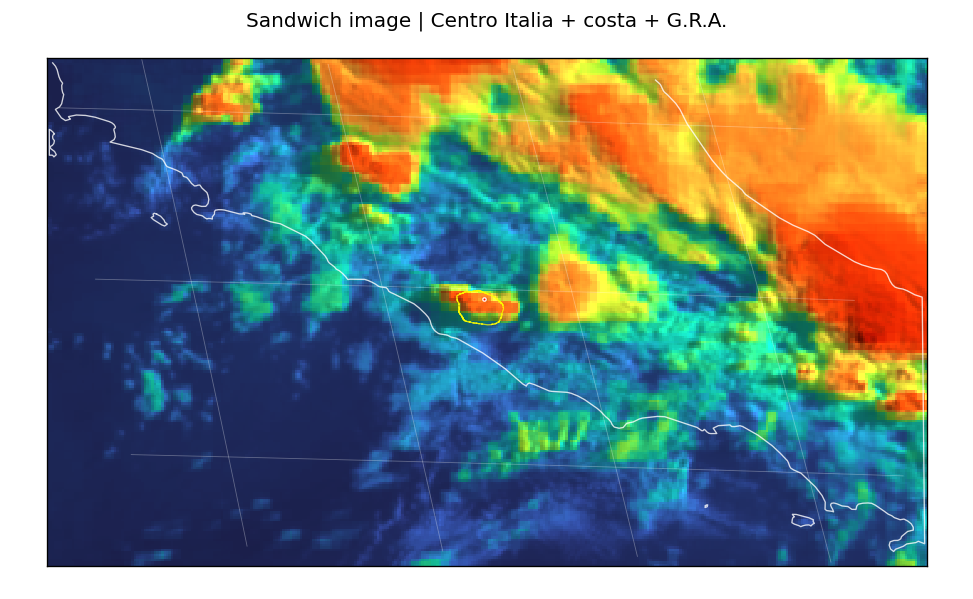

In [20]:
# Centro Italia: sandwich image con costa, G.R.A. e griglia lat/lon.
coastline_lines = globals().get("coastline_lines", fetch_coastline_lines())
CENTRAL_ITALY_COASTLINE_LINES = globals().get(
    "CENTRAL_ITALY_COASTLINE_LINES",
    filter_lonlat_lines_by_bbox(coastline_lines, CENTRAL_ITALY_BBOX, pad_degrees=0.75),
)
if "CENTRAL_ITALY_GRA_LINES" not in globals():
    try:
        CENTRAL_ITALY_GRA_LINES = filter_lonlat_lines_by_bbox(fetch_gra_lines(), CENTRAL_ITALY_BBOX, pad_degrees=0.05)
    except Exception as exc:
        CENTRAL_ITALY_GRA_LINES = []
        print(f"G.R.A. non disponibile al momento: {exc}")

central_vis, central_x, central_y = crop_channel_with_plan(product_dir, CENTRAL_ITALY_PLANS[VISIBLE_CHANNEL])
central_ir, _, _ = crop_channel_with_plan(product_dir, CENTRAL_ITALY_PLANS[THERMAL_CHANNEL])
central_sandwich = sandwich_composite(central_vis, central_ir)

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
plot_rgb_image(ax, central_sandwich, "Sandwich image | Centro Italia + costa + G.R.A.")
plot_lonlat_grid(ax, central_x, central_y, sample_file, CENTRAL_ITALY_BBOX, lon_step=1.0, lat_step=1.0, color="white", linewidth=0.5, alpha=0.30, fontsize=8)
plot_lonlat_lines(ax, CENTRAL_ITALY_COASTLINE_LINES, central_x, central_y, sample_file, color="white", linewidth=0.8, alpha=0.8)
if CENTRAL_ITALY_GRA_LINES:
    plot_lonlat_lines(ax, CENTRAL_ITALY_GRA_LINES, central_x, central_y, sample_file, color="yellow", linewidth=0.7, alpha=0.5)
plot_lonlat_point(ax, TARGET_LON, TARGET_LAT, central_x, central_y, sample_file, color="red", markersize=2)
plt.show()

In [ ]:
# Area di Roma: visibile con costa e G.R.A.
coastline_lines = globals().get("coastline_lines", fetch_coastline_lines())
ROME_COASTLINE_LINES = globals().get(
    "ROME_COASTLINE_LINES",
    filter_lonlat_lines_by_bbox(coastline_lines, ROME_BBOX, pad_degrees=0.75),
)
if "ROME_GRA_LINES" not in globals():
    try:
        ROME_GRA_LINES = filter_lonlat_lines_by_bbox(fetch_gra_lines(), ROME_BBOX, pad_degrees=0.05)
    except Exception as exc:
        ROME_GRA_LINES = []
        print(f"G.R.A. non disponibile al momento: {exc}")
rome_vis, rome_x, rome_y = crop_channel_with_plan(product_dir, ROME_PLANS[VISIBLE_CHANNEL])

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
plot_image(ax, rome_vis, VISIBLE_CHANNEL, f"{channel_title(VISIBLE_CHANNEL)} | Roma + G.R.A.")
plot_lonlat_lines(ax, ROME_COASTLINE_LINES, rome_x, rome_y, sample_file, color="cyan", linewidth=0.8, alpha=0.8)
if ROME_GRA_LINES:
    plot_lonlat_lines(ax, ROME_GRA_LINES, rome_x, rome_y, sample_file, color="lime", linewidth=1.5, alpha=0.95)
plot_lonlat_point(ax, TARGET_LON, TARGET_LAT, rome_x, rome_y, sample_file, color="red", markersize=8)
plt.show()

In [ ]:
# Area di Roma: sandwich image con costa e G.R.A.
coastline_lines = globals().get("coastline_lines", fetch_coastline_lines())
ROME_COASTLINE_LINES = globals().get(
    "ROME_COASTLINE_LINES",
    filter_lonlat_lines_by_bbox(coastline_lines, ROME_BBOX, pad_degrees=0.75),
)
if "ROME_GRA_LINES" not in globals():
    try:
        ROME_GRA_LINES = filter_lonlat_lines_by_bbox(fetch_gra_lines(), ROME_BBOX, pad_degrees=0.05)
    except Exception as exc:
        ROME_GRA_LINES = []
        print(f"G.R.A. non disponibile al momento: {exc}")
rome_vis, rome_x, rome_y = crop_channel_with_plan(product_dir, ROME_PLANS[VISIBLE_CHANNEL])
rome_ir, _, _ = crop_channel_with_plan(product_dir, ROME_PLANS[THERMAL_CHANNEL])
rome_sandwich = sandwich_composite(rome_vis, rome_ir)

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
plot_rgb_image(ax, rome_sandwich, "Sandwich image | Roma + G.R.A.")
plot_lonlat_lines(ax, ROME_COASTLINE_LINES, rome_x, rome_y, sample_file, color="white", linewidth=0.7, alpha=0.75)
if ROME_GRA_LINES:
    plot_lonlat_lines(ax, ROME_GRA_LINES, rome_x, rome_y, sample_file, color="yellow", linewidth=0.7, alpha=0.5)
plot_lonlat_point(ax, TARGET_LON, TARGET_LAT, rome_x, rome_y, sample_file, color="red", markersize=2)
plt.show()

## Video MP4

Le celle seguenti costruiscono un video `mp4` usando tutti i time frame disponibili. Il backend usato e' `ffmpeg`, quindi non servono librerie Python aggiuntive.

In [22]:
from datetime import datetime
from pathlib import Path
import re
import shutil
import subprocess

VIDEO_AREA = "central_italy"      # "rome" oppure "italy" oppure "central_italy"
VIDEO_STYLE = "sandwich" # "visible", "thermal" oppure "sandwich"
VIDEO_FPS = 4
VIDEO_DPI = 140
VIDEO_OUTDIR = Path(r"C:/Users/Daniele.LOKI/Documents/medicanes/MTG_data/video_outputs")
VIDEO_OUTDIR.mkdir(exist_ok=True)

assert VIDEO_AREA in {"rome", "italy", "central_italy"}
assert VIDEO_STYLE in {"visible", "thermal", "sandwich"}
assert shutil.which("ffmpeg"), "ffmpeg non trovato nel PATH"

AREA_CONFIG = {
    "italy": {
        "plans": ITALY_PLANS,
        "bbox": ITALY_BBOX,
        "coast": globals().get("ITALY_COASTLINE_LINES", []),
        "gra": [],
        "figsize": (8, 8),
        "title": "Italia",
    },
    "rome": {
        "plans": ROME_PLANS,
        "bbox": ROME_BBOX,
        "coast": globals().get("ROME_COASTLINE_LINES", []),
        "gra": globals().get("ROME_GRA_LINES", []),
        "figsize": (7, 7),
        "title": "Roma",
    },
    "central_italy": {
    "plans": CENTRAL_ITALY_PLANS,
    "bbox": CENTRAL_ITALY_BBOX,
    "coast": globals().get("CENTRAL_ITALY_COASTLINE_LINES", []),
    "gra": globals().get("CENTRAL_ITALY_GRA_LINES", []),
    "figsize": (8, 8),
    "title": "Centro Italia",
    },
}

VIDEO_CONFIG = AREA_CONFIG[VIDEO_AREA]
TIMESTAMP_RE = re.compile(r"(\d{14})")

print(f"Area video:   {VIDEO_AREA}")
print(f"Stile video:  {VIDEO_STYLE}")
print(f"FPS:          {VIDEO_FPS}")
print(f"Output dir:   {VIDEO_OUTDIR.resolve()}")

Area video:   central_italy
Stile video:  sandwich
FPS:          4
Output dir:   C:\Users\Daniele.LOKI\Documents\medicanes\MTG_data\video_outputs


In [23]:
def product_timestamp_label(product_path: Path) -> str:
    matches = TIMESTAMP_RE.findall(product_path.name)
    if not matches:
        return product_path.name
    try:
        dt = datetime.strptime(matches[0], "%Y%m%d%H%M%S")
        return dt.strftime("%Y-%m-%d %H:%M:%S UTC")
    except ValueError:
        return matches[0]


def render_video_frame(product_path: Path, *, area: str, style: str):
    cfg = AREA_CONFIG[area]
    plans = cfg["plans"]
    sample_file_local = list_body_files(product_path)[0]

    if style == "visible":
        image, x_grid, y_grid = crop_channel_with_plan(product_path, plans[VISIBLE_CHANNEL])
    elif style == "thermal":
        image, x_grid, y_grid = crop_channel_with_plan(product_path, plans[THERMAL_CHANNEL])
    else:
        vis, x_grid, y_grid = crop_channel_with_plan(product_path, plans[VISIBLE_CHANNEL])
        ir, _, _ = crop_channel_with_plan(product_path, plans[THERMAL_CHANNEL])
        image = sandwich_composite(vis, ir)

    fig, ax = plt.subplots(figsize=cfg["figsize"], constrained_layout=True)
    title = f"{cfg['title']} | {product_timestamp_label(product_path)}"

    if style == "visible":
        plot_image(ax, image, VISIBLE_CHANNEL, title)
        coast_color = "cyan"
        gra_color = "lime"
    elif style == "thermal":
        plot_image(ax, image, THERMAL_CHANNEL, title)
        coast_color = "white"
        gra_color = "cyan"
    else:
        plot_rgb_image(ax, image, title)
        coast_color = "white"
        gra_color = "yellow"

    if cfg["coast"]:
        plot_lonlat_lines(ax, cfg["coast"], x_grid, y_grid, sample_file_local, color=coast_color, linewidth=0.8, alpha=0.8)
    if cfg["gra"]:
        plot_lonlat_lines(ax, cfg["gra"], x_grid, y_grid, sample_file_local, color=gra_color, linewidth=0.7, alpha=0.5)
    plot_lonlat_point(ax, TARGET_LON, TARGET_LAT, x_grid, y_grid, sample_file_local, color="red", markersize=2)

    fig.canvas.draw()
    width, height = fig.canvas.get_width_height()
    frame = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(height, width, 4)[..., :3].copy()
    plt.close(fig)
    return frame


def write_mp4_ffmpeg(frame_iterable, out_path: Path, *, fps: int):
    frame_iter = iter(frame_iterable)
    first_frame = next(frame_iter)
    height, width, _ = first_frame.shape
    cmd = [
        shutil.which("ffmpeg"),
        "-y",
        "-f", "rawvideo",
        "-vcodec", "rawvideo",
        "-pix_fmt", "rgb24",
        "-s", f"{width}x{height}",
        "-r", str(fps),
        "-i", "-",
        "-an",
        "-vcodec", "libx264",
        "-pix_fmt", "yuv420p",
        str(out_path),
    ]
    proc = subprocess.Popen(cmd, stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    try:
        proc.stdin.write(first_frame.tobytes())
        for frame in frame_iter:
            proc.stdin.write(frame.tobytes())
        proc.stdin.close()
        _, stderr = proc.communicate()
    finally:
        if proc.stdin and not proc.stdin.closed:
            proc.stdin.close()
    if proc.returncode != 0:
        raise RuntimeError(stderr.decode("utf-8", errors="ignore"))
    return out_path

In [24]:
video_name = f"mtg_fci_{VIDEO_AREA}_{VIDEO_STYLE}_{len(products)}frames_{VIDEO_FPS}fps.mp4"
video_path = VIDEO_OUTDIR / video_name

print(f"Creo: {video_path}")

frames = []
for idx, product_path in enumerate(products, start=1):
    frame = render_video_frame(product_path, area=VIDEO_AREA, style=VIDEO_STYLE)
    frames.append(frame)
    print(f"Frame {idx}/{len(products)} pronto: {product_timestamp_label(product_path)}")

write_mp4_ffmpeg(frames, video_path, fps=VIDEO_FPS)
print(f"Video scritto in: {video_path.resolve()}")

Creo: C:\Users\Daniele.LOKI\Documents\medicanes\MTG_data\video_outputs\mtg_fci_central_italy_sandwich_15frames_4fps.mp4
Frame 1/15 pronto: 2026-06-03 05:02:55 UTC
Frame 2/15 pronto: 2026-06-03 05:12:59 UTC
Frame 3/15 pronto: 2026-06-03 05:22:57 UTC
Frame 4/15 pronto: 2026-06-03 05:33:01 UTC
Frame 5/15 pronto: 2026-06-03 05:43:03 UTC
Frame 6/15 pronto: 2026-06-03 05:53:19 UTC
Frame 7/15 pronto: 2026-06-03 06:02:57 UTC
Frame 8/15 pronto: 2026-06-03 06:12:59 UTC
Frame 9/15 pronto: 2026-06-03 06:23:02 UTC
Frame 10/15 pronto: 2026-06-03 06:33:01 UTC
Frame 11/15 pronto: 2026-06-03 06:43:04 UTC
Frame 12/15 pronto: 2026-06-03 06:53:16 UTC
Frame 13/15 pronto: 2026-06-03 07:03:07 UTC
Frame 14/15 pronto: 2026-06-03 07:13:07 UTC
Frame 15/15 pronto: 2026-06-03 07:23:11 UTC
Video scritto in: C:\Users\Daniele.LOKI\Documents\medicanes\MTG_data\video_outputs\mtg_fci_central_italy_sandwich_15frames_4fps.mp4
